# Detection tool training

In [7]:
# Import need libraries
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
import cv2
import matplotlib.pyplot as plt
import multiprocessing

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
df = pd.read_csv('..\data_pr\preprocessed\ch_metadata.csv')
# df = df[df['image_exists'] != False] # drop missing images
df = df.dropna(subset=['label']) # drop missing labels

print(f"Total samples: {len(df)}")
print(df['label'].value_counts())
df.head()

Total samples: 662
label
1    336
0    326
Name: count, dtype: int64


<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\MSI\AppData\Local\Temp\ipykernel_3412\2113075384.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('..\data_pr\preprocessed\ch_metadata.csv')


,image_id,filepath,label,age,sex
0,CHNCXR_0001_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,45.0,M
1,CHNCXR_0002_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,63.0,M
2,CHNCXR_0003_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,48.0,F
3,CHNCXR_0004_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,58.0,M
4,CHNCXR_0005_0,..\data_pr\Raw\Chinaset_AllFiles\CXR_png\CHNCX...,0,28.0,M


In [4]:
# Splitting
train_df, temp_df = train_test_split(df, test_size = 0.2, stratify=df['label'], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size = 0.5, stratify=temp_df['label'], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain label balance:\n{train_df['label'].value_counts(normalize=True)}")

Train: 529 | Val: 66 | Test: 67

Train label balance:
label
1    0.506616
0    0.493384
Name: proportion, dtype: float64


In [5]:
# Preprocessing transforms (Resize + Normalize)
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])  # ImageNet stats
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

In [6]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
print(f"Current device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

CUDA available: True
Device count: 1
Current device: NVIDIA GeForce RTX 3060


In [11]:
# Custom pytorch Dataset
class TBXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {row['filepath']}")

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)  # DenseNet expects 3 channels

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label


train_dataset = TBXrayDataset(train_df, transform=train_transform)
val_dataset = TBXrayDataset(val_df, transform=val_test_transform)
test_dataset = TBXrayDataset(test_df, transform=val_test_transform)

# NUM_WORKERS = max(1, multiprocessing.cpu_count() - 2)  # Use all but one CPU core
NUM_WORKERS = 0
print(f"Using {NUM_WORKERS} workers for data loading.")

train_loader = DataLoader(train_dataset, 
                          batch_size=64, # GPU usage increase (64 : 5 - 7GB vram using)
                          shuffle=True, 
                          num_workers=NUM_WORKERS, # multi core of CPU using
                          pin_memory=True # speed up cpu, GPU transfer
                    ) # workers alive between epochs
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Using 0 workers for data loading.
Train batches: 9 | Val batches: 2


Batch shape: torch.Size([64, 3, 224, 224])
Labels: tensor([1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
        1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
        1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0])


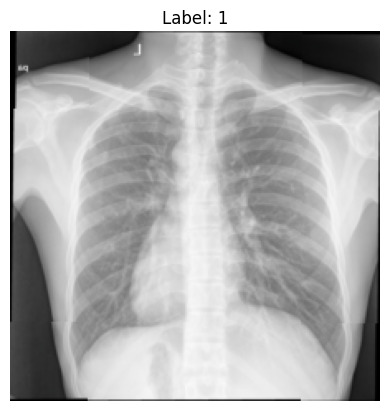

In [12]:
# Sanity ceck: Visualize a few samples from the training set
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")  # should be [16, 3, 224, 224]
print(f"Labels: {labels}")

# Unnormalize for viewing
img_show = images[0].permute(1, 2, 0).numpy()
img_show = img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
img_show = np.clip(img_show, 0, 1)

plt.imshow(img_show)
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

In [13]:
# Build baseline DenseNet model
model = models.densenet121(weights='DEFAULT')  # pretrained on ImageNet

#Dense net default is 1000 class but we need to change it to 2 classes for our binary classification task
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 2)

model = model.to(device)
print(model.classifier)  # Confirm out is 2 class

Linear(in_features=1024, out_features=2, bias=True)


In [14]:
# Loss function
# Calculate class weights to handle imbalance
class_counts = train_df['label'].value_counts().sort_index()
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"Class weights: {class_weights}")

Class weights: tensor([0.0038, 0.0037], device='cuda:0')


In [15]:
# Training loop
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 0.5294 Acc: 0.7505 | Val Loss: 0.6311 Acc: 0.7424
Epoch 2/10 | Train Loss: 0.3844 Acc: 0.8374 | Val Loss: 0.5041 Acc: 0.7727
Epoch 3/10 | Train Loss: 0.3039 Acc: 0.8658 | Val Loss: 0.3361 Acc: 0.8030
Epoch 4/10 | Train Loss: 0.2671 Acc: 0.8941 | Val Loss: 0.2895 Acc: 0.8636
Epoch 5/10 | Train Loss: 0.2222 Acc: 0.9168 | Val Loss: 0.3030 Acc: 0.8485
Epoch 6/10 | Train Loss: 0.1964 Acc: 0.9376 | Val Loss: 0.2738 Acc: 0.7424
Epoch 7/10 | Train Loss: 0.1905 Acc: 0.9357 | Val Loss: 0.3391 Acc: 0.8485
Epoch 8/10 | Train Loss: 0.1716 Acc: 0.9509 | Val Loss: 0.4877 Acc: 0.7879
Epoch 9/10 | Train Loss: 0.1144 Acc: 0.9546 | Val Loss: 0.3848 Acc: 0.8182
Epoch 10/10 | Train Loss: 0.0722 Acc: 0.9868 | Val Loss: 0.4865 Acc: 0.8030


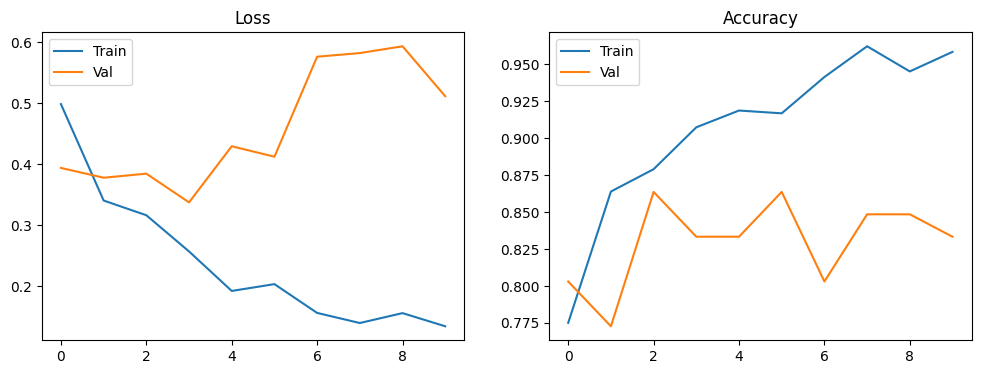

In [15]:
# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.show()

In [ ]:
# Save the Baseline model
# os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/baseline_densenet121_shenzhen.pth")
print("Baseline model saved!")

Baseline model saved!
